# ASSIGNMENT GROUP 12 NOTEBOOK


In [214]:
from __future__ import annotations

from pathlib import Path

import io
import zipfile
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests  # used only if we download Fama-French data
except Exception:
    requests = None

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [215]:
if importlib.util.find_spec('statsmodels') is None:
    raise ModuleNotFoundError(
        "Lecture 4 requires statsmodels. In Jupyter, run: %pip install statsmodels"
    )

import statsmodels.api as sm


## Data Loading and Basic Checks

We load a single Charting Excel Export file from Capital IQ:
- **Data:** monthly dividend-adjusted share prices for FGNX, EAT, CLB, CLX and **SPY** (S&P 500 proxy) (`Charting Excel Export - Stocks.xls`)

The export contains dividend-adjusted price levels $P_t$, so monthly simple returns are computed via:

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

After computing returns, SPY is separated from the four stock series. All series are resampled to beginning-of-month frequency before merging.

In [216]:
import re

DATA_PATH = '/content/sample_data/Charting Excel Export - Screen 4.xls'

START_DATE = pd.Timestamp('01/01/1998')
END_DATE   = pd.Timestamp('31/12/2024')


def _load_charting_xls(path: str) -> pd.DataFrame:
    """
    Read an Excel Export file (Pane 1 sheet) from Capital IQ.
    Returns a beginning-of-month DatetimeIndex DataFrame.

    Capital IQ labels end-of-month prices on the 1st of the following month
    when the month ends on a weekend or holiday. Shift those dates back one day
    so they are grouped with the correct prior month before resampling.
    """
    raw = pd.read_excel(path, sheet_name='Pane 1', header=None)
    mask = raw.notna().any(axis=1)
    data = raw[mask].copy()
    data.columns = data.iloc[0]          # first surviving row is the header
    data = data.iloc[1:].copy()
    data = data.rename(columns={data.columns[0]: 'date'})
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date').apply(pd.to_numeric, errors='coerce')
    # Dates on the 1st of a month are end-of-prior-month prices reported on the
    # next business day. Shift them back one day into the correct month.
    data.index = data.index - pd.to_timedelta((data.index.day == 1).astype(int), unit='D')
    # Group by calendar month (last observation), then label beginning-of-month
    # to match the Fama-French date convention.
    data = data.resample('ME').last()
    data.index = data.index.to_period('M').to_timestamp()
    return data


def _extract_ticker(col: str) -> str:
    """Pull the ticker symbol out of a long Charting column label."""
    m = re.search(r'\((?:[A-Za-z]+:)?([A-Z]+)\)', col)
    return m.group(1) if m else col


# ── Load all assets from a single file ────────────────────────────────────────
all_prices = _load_charting_xls(DATA_PATH)
all_prices.columns = [_extract_ticker(c) for c in all_prices.columns]

# Dividend-adjusted price levels → monthly simple return
# r_t = P_t / P_{t-1} - 1
all_ret = all_prices.pct_change().dropna(how='all')

# ── Split stocks and S&P 500 proxy (SPY) ──────────────────────────────────────
stock_tickers = [c for c in all_ret.columns if c != 'SPY']
stocks_prices = all_prices[stock_tickers]   # kept for stock-selection cell below
stocks_ret    = all_ret[stock_tickers]
spy_ret       = all_ret[['SPY']]

# ── Merge stocks + SPY ────────────────────────────────────────────────────────
df_ret = stocks_ret.join(spy_ret, how='inner').dropna(how='all')
df_ret.index.name = 'date'

df_ret = df_ret.loc[START_DATE:END_DATE]

print(f'Data file    : {DATA_PATH}')
print(f'Rows (months): {df_ret.shape[0]}, Columns (assets): {df_ret.shape[1]}')
print(f'Date range   : {df_ret.index.min().date()} to {df_ret.index.max().date()}')
df_ret.head()

Data file    : /content/sample_data/Charting Excel Export - Screen 4.xls
Rows (months): 324, Columns (assets): 8
Date range   : 1998-01-01 to 2024-12-01


,STZ,MYGN,INTC,Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,MAC,MU,RDN,SPY
date,,,,,,,,
1998-01-01,-0.018605,-0.037838,0.141526,0.058559,0.017977,0.381546,0.074816,0.041986
1998-02-01,0.079384,-0.146068,0.162287,0.387234,0.014198,0.003610,0.078950,0.069715
1998-03-01,0.003293,0.177632,-0.169548,-0.006135,0.053097,-0.163669,-0.029091,0.054745
1998-04-01,-0.083151,-0.072626,0.035620,-0.120370,-0.056723,0.068817,-0.032772,0.012791
1998-05-01,-0.119332,-0.030121,-0.116009,-0.147368,-0.022113,-0.241449,-0.062488,-0.020769


In [217]:
df_ret.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 324 entries, 1998-01-01 to 2024-12-01
Freq: MS
Data columns (total 8 columns):
 #   Column                                                                                            Non-Null Count  Dtype  
---  ------                                                                                            --------------  -----  
 0   STZ                                                                                               324 non-null    float64
 1   MYGN                                                                                              324 non-null    float64
 2   INTC                                                                                              324 non-null    float64
 3   Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing  324 non-null    float64
 4   MAC                                                                                               324

In [218]:
# Full descriptive statistics for all available assets.
df_ret.describe().T

,count,mean,std,min,25%,50%,75%,max
STZ,324.000000,0.014597,0.081489,-0.402985,-0.029579,0.013017,0.060531,0.402799
MYGN,324.000000,0.018113,0.183024,-0.603618,-0.086601,0.005963,0.097284,1.112945
INTC,324.000000,0.007457,0.100373,-0.444908,-0.047106,0.012363,0.064582,0.265166
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,324.000000,0.018004,0.088937,-0.270313,-0.026433,0.015363,0.060842,0.387234
MAC,324.000000,0.016873,0.173148,-0.711619,-0.048091,0.013407,0.058956,2.022414
MU,324.000000,0.018713,0.159171,-0.499335,-0.078543,0.016273,0.106589,0.711375
RDN,324.000000,0.018050,0.193848,-0.746946,-0.049823,0.008379,0.080654,1.754571
SPY,324.000000,0.008295,0.046539,-0.224162,-0.016414,0.013142,0.036947,0.146239


## Risk-Free Rate ($r_f$) and Market Excess Return via Fama--French

As in Lecture 2, we merge the stock-return dataset with the Ken French factor file.
We need two columns for the CAPM:
- `RF`: the monthly risk-free rate,
- `Mkt-RF`: the market excess return.

The Ken French file reports values in percent, so we divide by 100 to convert them to decimal returns.

In [219]:
USE_FAMA_FRENCH_RF = True

# Ken French data library (Dartmouth) — loading the data directly from the URL.
FF_ZIP_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
LOCAL_FF_ZIP = Path('../../Lecture_2/Code/Source/F-F_Research_Data_5_Factors_2x3_CSV.zip')


In [220]:
def read_ff_zip(zip_bytes: bytes) -> pd.DataFrame:
    z = zipfile.ZipFile(io.BytesIO(zip_bytes))
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as file:
        df_factors = pd.read_csv(file, skiprows=3, index_col=0)

    # Keep monthly data only (cut before the annual section begins).
    df_factors = df_factors.loc[:'202412']
    df_factors.index = pd.to_datetime(df_factors.index, format='%Y%m')
    df_factors = df_factors.apply(pd.to_numeric) / 100.0  # convert % to decimal
    df_factors = df_factors.rename_axis('date').reset_index()
    return df_factors


if USE_FAMA_FRENCH_RF:
    try:
        if requests is None:
            raise ModuleNotFoundError('requests is not available')

        # Download the ZIP file
        response = requests.get(FF_ZIP_URL, timeout=30)
        response.raise_for_status()
        df_factors = read_ff_zip(response.content)

        # Merge with returns (inner join: keeps only common dates).
        df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        print('Using Ken French website download.')

    except Exception as e:
        if LOCAL_FF_ZIP.exists():
            print(f'Download failed ({type(e).__name__}). Using local fallback ZIP instead.')
            df_factors = read_ff_zip(LOCAL_FF_ZIP.read_bytes())
            df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        else:
            print(f'Download failed ({type(e).__name__}). Proceeding with r_f = 0.')
            USE_FAMA_FRENCH_RF = False

else:
    # Offline/error fallback: proceed with r_f = 0 and no factor columns.
    df = df_ret.copy()

print(f'Merged dataset rows: {df.shape[0]}, date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()


Using Ken French website download.
Merged dataset rows: 324, date range: 1998-01-01 to 2024-12-01


,STZ,MYGN,INTC,Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,MAC,MU,RDN,SPY,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,,,,,,,,
1998-01-01,-0.018605,-0.037838,0.141526,0.058559,0.017977,0.381546,0.074816,0.041986,0.001400,-0.012800,-0.016800,0.009100,-0.006200,0.004300
1998-02-01,0.079384,-0.146068,0.162287,0.387234,0.014198,0.003610,0.078950,0.069715,0.070400,0.000500,-0.009300,-0.003700,-0.025800,0.003900
1998-03-01,0.003293,0.177632,-0.169548,-0.006135,0.053097,-0.163669,-0.029091,0.054745,0.047600,-0.007300,0.013800,-0.005500,-0.002300,0.003900
1998-04-01,-0.083151,-0.072626,0.035620,-0.120370,-0.056723,0.068817,-0.032772,0.012791,0.007400,0.000100,0.010300,-0.016800,-0.003600,0.004300
1998-05-01,-0.119332,-0.030121,-0.116009,-0.147368,-0.022113,-0.241449,-0.062488,-0.020769,-0.030500,-0.030000,0.034100,0.010300,0.024700,0.004000


In [221]:
def run_capm_table(returns: pd.DataFrame, market_excess: pd.Series, rf: pd.Series) -> pd.DataFrame:
    rows = []
    for ticker in returns.columns:
        X = sm.add_constant(market_excess)
        y = returns[ticker] - rf
        model = sm.OLS(y, X).fit()

        rows.append({
            'Ticker': ticker,
            'Mean excess return (monthly)': y.mean(),
            'CAPM required excess return (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
            'Alpha (monthly)': model.params['const'],
            'Alpha (annualised)': (1 + model.params['const']) ** 12 - 1,
            'Beta': model.params['Mkt-RF'],
            'Alpha t-stat': model.tvalues['const'],
            'R-squared': model.rsquared,
        })

    return pd.DataFrame(rows).sort_values(['Alpha (monthly)', 'Alpha t-stat'], ascending=False).set_index('Ticker')

In [222]:
available_tickers = df_ret.columns.tolist()
market_excess = df['Mkt-RF'] if USE_FAMA_FRENCH_RF and 'Mkt-RF' in df.columns else pd.Series(0.0, index=df.index, name='Mkt-RF')
rf = df['RF'] if USE_FAMA_FRENCH_RF and 'RF' in df.columns else pd.Series(0.0, index=df.index, name='RF')

alpha_table = run_capm_table(df_ret[available_tickers], market_excess, rf)
my_stock_selection = alpha_table.head(7).index.tolist()

print('Top 7 high-alpha assets from the full sample:')
print(my_stock_selection)
alpha_table.head(10)

Top 7 high-alpha assets from the full sample:
['Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing', 'STZ', 'MYGN', 'MU', 'RDN', 'MAC', 'SPY']


,Mean excess return (monthly),CAPM required excess return (monthly),Alpha (monthly),Alpha (annualised),Beta,Alpha t-stat,R-squared
Ticker,,,,,,,
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.016354,0.006505,0.009849,0.124805,0.969596,2.283573,0.256113
STZ,0.012946,0.004813,0.008133,0.102084,0.717463,1.939325,0.166237
MYGN,0.016462,0.008738,0.007724,0.096724,1.302558,0.795924,0.109322
MU,0.017063,0.010453,0.006610,0.082269,1.558071,0.829091,0.206459
RDN,0.016399,0.010526,0.005873,0.072803,1.568991,0.581085,0.141002
MAC,0.015222,0.010161,0.005061,0.062449,1.514673,0.568598,0.164779
SPY,0.006644,0.006246,0.000398,0.004790,0.931044,0.406073,0.859890
INTC,0.005807,0.008006,-0.002200,-0.026079,1.193420,-0.467211,0.304454


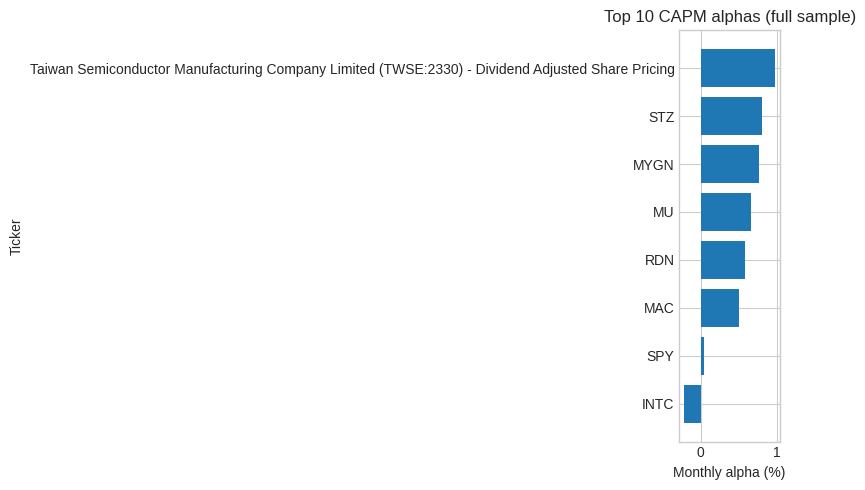

In [223]:
plot_table = alpha_table.head(10).copy().iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_table.index, 100 * plot_table['Alpha (monthly)'], color='tab:blue')
ax.set_title('Top 10 CAPM alphas (full sample)')
ax.set_xlabel('Monthly alpha (%)')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.show()

## Stock Selection


In [224]:
market_excess = df['Mkt-RF'] if USE_FAMA_FRENCH_RF and 'Mkt-RF' in df.columns else pd.Series(0.0, index=df.index, name='Mkt-RF')
rf = df['RF'] if USE_FAMA_FRENCH_RF and 'RF' in df.columns else pd.Series(0.0, index=df.index, name='RF')

my_stock_selection = stocks_prices.columns.tolist()

print('Selected stocks:')
print(my_stock_selection)


Selected stocks:
['STZ', 'MYGN', 'INTC', 'Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing', 'MAC', 'MU', 'RDN']


In [225]:
missing = sorted(set(my_stock_selection) - set(df.columns))
if missing:
    raise ValueError(f'Tickers not found in data: {missing}')

stocks = df[my_stock_selection].copy()
stocks.describe().T


,count,mean,std,min,25%,50%,75%,max
STZ,324.000000,0.014597,0.081489,-0.402985,-0.029579,0.013017,0.060531,0.402799
MYGN,324.000000,0.018113,0.183024,-0.603618,-0.086601,0.005963,0.097284,1.112945
INTC,324.000000,0.007457,0.100373,-0.444908,-0.047106,0.012363,0.064582,0.265166
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,324.000000,0.018004,0.088937,-0.270313,-0.026433,0.015363,0.060842,0.387234
MAC,324.000000,0.016873,0.173148,-0.711619,-0.048091,0.013407,0.058956,2.022414
MU,324.000000,0.018713,0.159171,-0.499335,-0.078543,0.016273,0.106589,0.711375
RDN,324.000000,0.018050,0.193848,-0.746946,-0.049823,0.008379,0.080654,1.754571


## Correlations (Diversification Intuition)

Correlation is not the optimisation input (that is $\Sigma$), but it is still a quick way to see whether diversification is likely to help.

In [226]:
corr = stocks.corr()
corr

,STZ,MYGN,INTC,Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,MAC,MU,RDN
STZ,1.000000,0.043208,0.179984,0.176526,0.266268,0.229294,0.256666
MYGN,0.043208,1.000000,0.285634,0.214277,0.131604,0.177387,0.111083
INTC,0.179984,0.285634,1.000000,0.473900,0.205941,0.557627,0.172371
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.176526,0.214277,0.473900,1.000000,0.186893,0.352855,0.142157
MAC,0.266268,0.131604,0.205941,0.186893,1.000000,0.208622,0.265969
MU,0.229294,0.177387,0.557627,0.352855,0.208622,1.000000,0.243976
RDN,0.256666,0.111083,0.172371,0.142157,0.265969,0.243976,1.000000


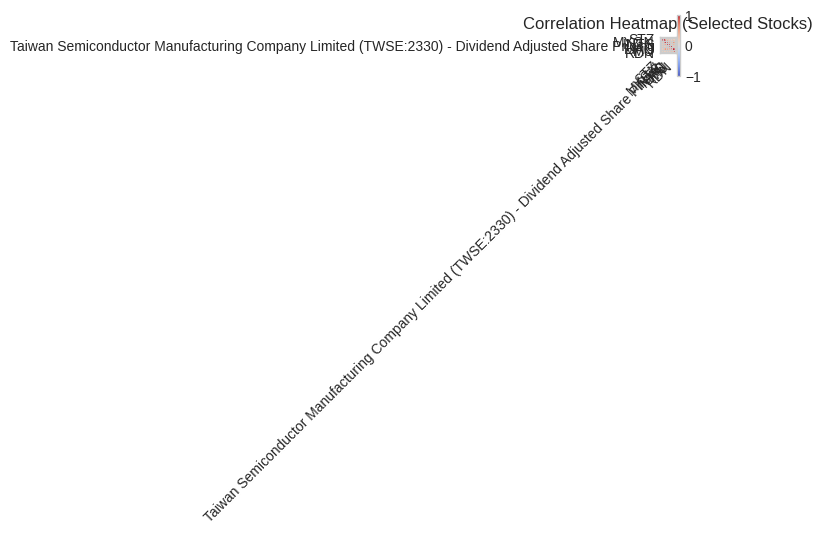

In [227]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(my_stock_selection)))
ax.set_yticks(range(len(my_stock_selection)))
ax.set_xticklabels(my_stock_selection, rotation=45, ha='right')
ax.set_yticklabels(my_stock_selection)
ax.set_title('Correlation Heatmap (Selected Stocks)')
fig.colorbar(image, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()


## Portfolio Inputs: $\mu$ and $\Sigma$

For portfolio weights $w$ and return vector $r$:
- Expected excess return: $\mathbb{E}[r_p^e] = w^\top \mu^e$
- Variance: $\mathrm{Var}(r_p) = w^\top \Sigma w$

We estimate $\Sigma$ from historical data exactly as in Lecture 2.

In [228]:
# Population-style covariance estimate from the lecture notes: Sigma_hat = (1/T) R^T R
R = stocks.subtract(stocks.mean())
T = len(stocks)
Sigma_pop = (R.T @ R) / T

# Unbiased sample estimate divides by (T-1) instead.
Sigma_samp = (R.T @ R) / (T - 1)

Sigma = Sigma_samp
Sigma.head()

,STZ,MYGN,INTC,Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,MAC,MU,RDN
STZ,0.006640,0.000644,0.001472,0.001279,0.003757,0.002974,0.004054
MYGN,0.000644,0.033498,0.005247,0.003488,0.004171,0.005168,0.003941
INTC,0.001472,0.005247,0.010075,0.004230,0.003579,0.008909,0.003354
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.001279,0.003488,0.004230,0.007910,0.002878,0.004995,0.002451
MAC,0.003757,0.004171,0.003579,0.002878,0.029980,0.005750,0.008927


## Excess Returns

The tangency portfolio uses the vector of expected excess returns:

$$\mu^e = \mathbb{E}[r_t - r_{f,t}].$$

In [229]:
stocks_excess = stocks.subtract(rf, axis=0)
mu_e = stocks_excess.mean()
mu_e

,0
STZ,0.012946
MYGN,0.016462
INTC,0.005807
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.016354
MAC,0.015222
MU,0.017063
RDN,0.016399


## Markowitz Tangency (Maximum Sharpe) Portfolio

With weights summing to one ($\mathbf{1}^\top w = 1$), the tangency portfolio weights are:

$$w^\star = \frac{\Sigma^{-1}\mu^e}{\mathbf{1}^\top\Sigma^{-1}\mu^e}.$$

In [230]:
def tangency_weights(Sigma: np.ndarray, mu_excess: np.ndarray) -> np.ndarray:
    mu_excess = np.asarray(mu_excess, dtype=float).reshape(-1)
    ones = np.ones_like(mu_excess)

    z = np.linalg.pinv(Sigma) @ mu_excess

    denom = ones @ z
    if np.isclose(denom, 0.0):
        raise ValueError('Normalisation failed: 1^T Σ^{+} μ^e is ~0.')

    return z / denom


In [231]:
w_mkv = tangency_weights(Sigma.values if hasattr(Sigma, 'values') else Sigma, mu_e.values)
w_mkv = pd.Series(w_mkv, index=my_stock_selection, name='Mean-variance optimal')

w_eq = pd.Series(np.repeat(1 / len(my_stock_selection), len(my_stock_selection)), index=my_stock_selection, name='Equal-weighted')

weights_compare = pd.concat([w_eq, w_mkv], axis=1)
weights_compare

,Equal-weighted,Mean-variance optimal
STZ,0.142857,0.448895
MYGN,0.142857,0.102910
INTC,0.142857,-0.304944
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.142857,0.581454
MAC,0.142857,0.033562
MU,0.142857,0.105128
RDN,0.142857,0.032995


/tmp/ipykernel_16255/4098721044.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


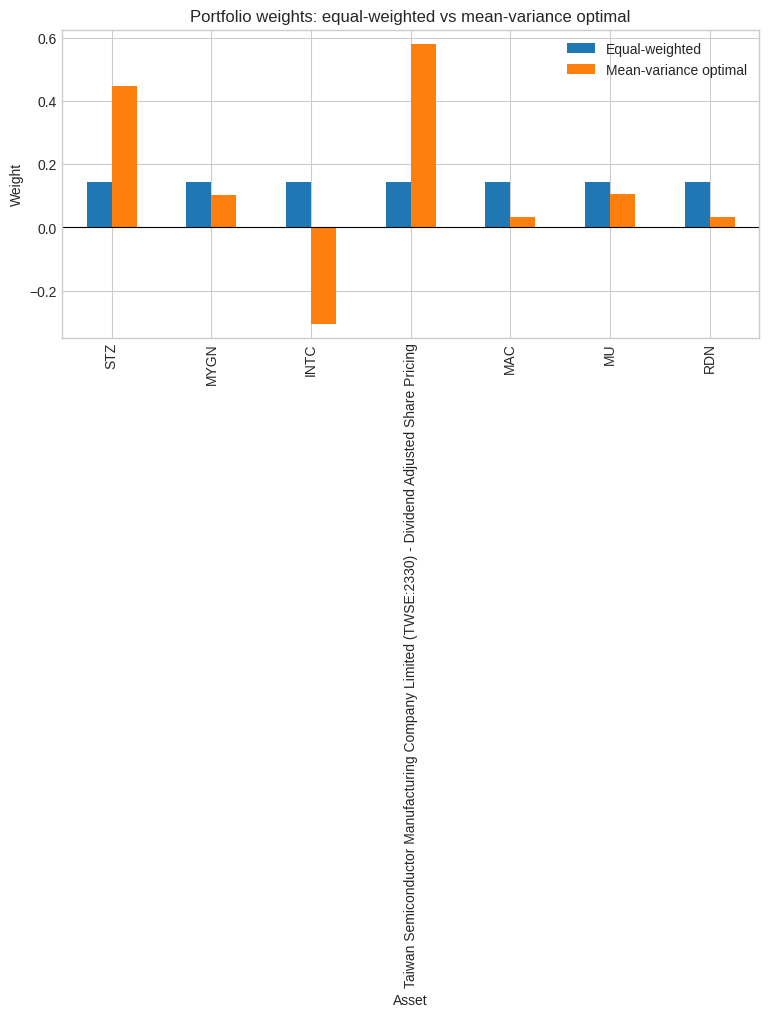

In [232]:
ax = weights_compare.plot(kind='bar', figsize=(9, 4), title='Portfolio weights: equal-weighted vs mean-variance optimal')
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## CAPM Evaluation of the Portfolios

After the portfolios are formed, we can still use the CAPM as a benchmark. We run the CAPM regression again, now on the **portfolio excess return**.

In [233]:
def portfolio_capm_summary(weights: pd.Series, returns: pd.DataFrame, rf: pd.Series, market_excess: pd.Series) -> pd.Series:
    portfolio_total = returns @ weights
    portfolio_excess = portfolio_total - rf

    X = sm.add_constant(market_excess)
    model = sm.OLS(portfolio_excess, X).fit()

    mean_excess = portfolio_excess.mean()
    sig = portfolio_excess.std(ddof=1)

    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': model.params['Mkt-RF'],
        'CAPM required excess (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
        'CAPM alpha (monthly)': model.params['const'],
        'CAPM alpha t-stat': model.tvalues['const'],
        'R-squared': model.rsquared,
    }, name=weights.name)


def market_capm_summary(market_excess: pd.Series) -> pd.Series:
    """CAPM benchmark row for the market portfolio.
    By construction: beta = 1, alpha = 0, R-squared = 1."""
    mean_excess = market_excess.mean()
    sig = market_excess.std(ddof=1)
    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': 1.0,
        'CAPM required excess (monthly)': mean_excess,
        'CAPM alpha (monthly)': 0.0,
        'CAPM alpha t-stat': 0.0,
        'R-squared': 1.0,
    }, name='Market')


perf_full = pd.concat([
    portfolio_capm_summary(w_eq, stocks, rf, market_excess),
    portfolio_capm_summary(w_mkv, stocks, rf, market_excess),
    market_capm_summary(market_excess),
], axis=1).T
perf_full

,E[excess] (monthly),Vol (monthly),Sharpe (monthly),CAPM beta,CAPM required excess (monthly),CAPM alpha (monthly),CAPM alpha t-stat,R-squared
Equal-weighted,0.014322,0.081959,0.174743,1.260682,0.008457,0.005864,1.817983,0.509928
Mean-variance optimal,0.018090,0.074037,0.244332,0.922362,0.006188,0.011902,3.505000,0.334501
Market,0.006709,0.046424,0.144507,1.000000,0.006709,0.000000,0.000000,1.000000


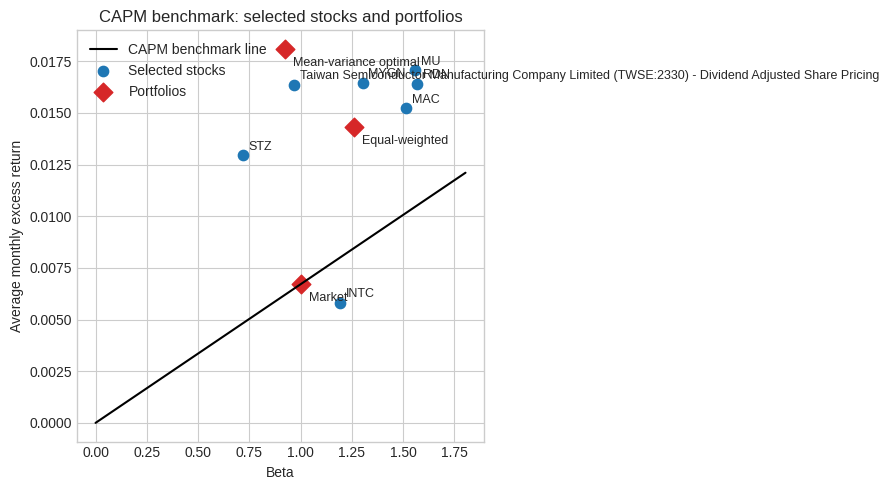

In [234]:
market_premium = market_excess.mean()
asset_points = alpha_table.loc[my_stock_selection, ['Beta', 'Mean excess return (monthly)']].copy()

fig, ax = plt.subplots(figsize=(8, 5))

beta_grid = np.linspace(0, max(asset_points['Beta'].max(), perf_full['CAPM beta'].max()) * 1.15, 100)
ax.plot(beta_grid, market_premium * beta_grid, color='black', linewidth=1.5, label='CAPM benchmark line')
ax.scatter(asset_points['Beta'], asset_points['Mean excess return (monthly)'], color='tab:blue', s=55, label='Selected stocks')
ax.scatter(perf_full['CAPM beta'], perf_full['E[excess] (monthly)'], color='tab:red', marker='D', s=90, label='Portfolios')

for ticker, row in asset_points.iterrows():
    ax.annotate(ticker, (row['Beta'], row['Mean excess return (monthly)']), xytext=(4, 4), textcoords='offset points', fontsize=9)
for portfolio_name, row in perf_full.iterrows():
    ax.annotate(portfolio_name, (row['CAPM beta'], row['E[excess] (monthly)']), xytext=(6, -12), textcoords='offset points', fontsize=9)

ax.set_title('CAPM benchmark: selected stocks and portfolios')
ax.set_xlabel('Beta')
ax.set_ylabel('Average monthly excess return')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## In-Sample / Out-of-Sample Analysis

Up to this point, we have used the **full sample** for both selection and evaluation. That is useful for teaching the mechanics, but it can be overly optimistic.

We now split the sample at **January 2015**, giving:
- **In-sample:** 1998–2014 (204 months, ~63% of the data)
- **Out-of-sample:** 2015–2024 (120 months, ~37% of the data)

The split date is controlled by `SPLIT_DATE` below and can be moved to explore different windows. The seven stocks and the portfolio weights are chosen using only the in-sample data. Then we evaluate those same choices out-of-sample.

In [235]:
# Change SPLIT_DATE to move the in-sample/out-of-sample boundary.
# Must fall within the dataset range: 1998-01-01 to 2024-12-01.
SPLIT_DATE = pd.Timestamp('2015-01-01')

train = df.loc[df.index < SPLIT_DATE].copy()
test  = df.loc[df.index >= SPLIT_DATE].copy()

print(f'Split date: {SPLIT_DATE.date()}')
print(f'In-sample observations:     {len(train)}')
print(f'Out-of-sample observations: {len(test)}')

Split date: 2015-01-01
In-sample observations:     204
Out-of-sample observations: 120


In [236]:
train_alpha_table = run_capm_table(train[df_ret.columns], train['Mkt-RF'], train['RF'])
train_selection = train_alpha_table.head(7).index.tolist()

print('Top 7 in-sample alpha assets:')
print(train_selection)
train_alpha_table.head(10)

Top 7 in-sample alpha assets:
['MYGN', 'MAC', 'STZ', 'RDN', 'MU', 'Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing', 'INTC']


,Mean excess return (monthly),CAPM required excess return (monthly),Alpha (monthly),Alpha (annualised),Beta,Alpha t-stat,R-squared
Ticker,,,,,,,
MYGN,0.025131,0.005449,0.019683,0.263514,1.117710,1.459331,0.069549
MAC,0.020623,0.006128,0.014495,0.188493,1.257075,1.213985,0.107663
STZ,0.015586,0.003495,0.012090,0.155132,0.716991,2.042795,0.137733
RDN,0.020319,0.009060,0.011258,0.143787,1.858520,0.735034,0.138118
MU,0.018680,0.007956,0.010723,0.136549,1.632036,0.952974,0.186301
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.013615,0.005266,0.008349,0.104925,1.080117,1.439580,0.274037
INTC,0.009238,0.006264,0.002974,0.036280,1.284978,0.485406,0.323728
SPY,0.004709,0.004435,0.000274,0.003288,0.909769,0.200178,0.828288


In [237]:
stocks_train = train[my_stock_selection].copy()
stocks_excess_train = stocks_train.subtract(train['RF'], axis=0)
mu_e_train = stocks_excess_train.mean()

R_train = stocks_train.subtract(stocks_train.mean())
T_train = len(stocks_train)
Sigma_train = (R_train.T @ R_train) / (T_train - 1)

w_mkv_train = tangency_weights(Sigma_train.values if hasattr(Sigma_train, 'values') else Sigma_train, mu_e_train.values)
w_mkv_train = pd.Series(w_mkv_train, index=my_stock_selection, name='Mean-variance optimal')

w_eq_train = pd.Series(np.repeat(1 / len(my_stock_selection), len(my_stock_selection)), index=my_stock_selection, name='Equal-weighted')

pd.concat([w_eq_train, w_mkv_train], axis=1)

,Equal-weighted,Mean-variance optimal
STZ,0.142857,0.466336
MYGN,0.142857,0.176410
INTC,0.142857,-0.157169
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,0.142857,0.319831
MAC,0.142857,0.114345
MU,0.142857,0.073593
RDN,0.142857,0.006655


In [238]:
perf_train = pd.concat([
    portfolio_capm_summary(w_eq_train, train[my_stock_selection], train['RF'], train['Mkt-RF']),
    portfolio_capm_summary(w_mkv_train, train[my_stock_selection], train['RF'], train['Mkt-RF']),
    market_capm_summary(train['Mkt-RF']),
], axis=1).T
perf_train.insert(0, 'Sample', 'In-sample')

perf_test = pd.concat([
    portfolio_capm_summary(w_eq_train, test[my_stock_selection], test['RF'], test['Mkt-RF']),
    portfolio_capm_summary(w_mkv_train, test[my_stock_selection], test['RF'], test['Mkt-RF']),
    market_capm_summary(test['Mkt-RF']),
], axis=1).T
perf_test.insert(0, 'Sample', 'Out-of-sample')

perf_split = pd.concat([perf_train, perf_test])
perf_split

,Sample,E[excess] (monthly),Vol (monthly),Sharpe (monthly),CAPM beta,CAPM required excess (monthly),CAPM alpha (monthly),CAPM alpha t-stat,R-squared
Equal-weighted,In-sample,0.017599,0.086446,0.203582,1.278204,0.006231,0.011368,2.578699,0.477832
Mean-variance optimal,In-sample,0.018472,0.073643,0.250832,0.951244,0.004637,0.013835,3.339764,0.364652
Market,In-sample,0.004875,0.046750,0.104278,1.000000,0.004875,0.000000,0.000000,1.000000
Equal-weighted,Out-of-sample,0.008751,0.073723,0.118700,1.252184,0.012304,-0.003553,-0.820402,0.607562
Mean-variance optimal,Out-of-sample,0.012782,0.069746,0.183263,1.061085,0.010426,0.002356,0.503142,0.487449
Market,Out-of-sample,0.009826,0.045891,0.214110,1.000000,0.009826,0.000000,0.000000,1.000000


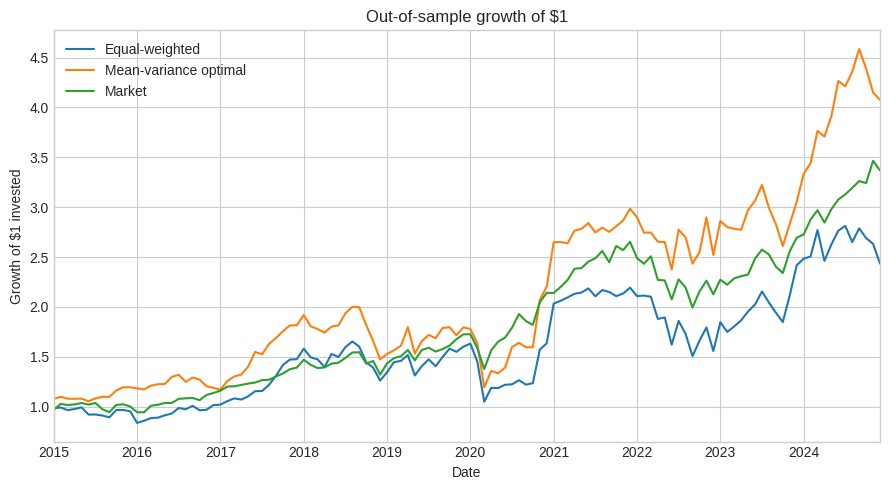

In [239]:
portfolio_eq_test = test[my_stock_selection] @ w_eq_train
portfolio_mkv_test = test[my_stock_selection] @ w_mkv_train
market_test = test['Mkt-RF'] + test['RF']

wealth_paths = pd.DataFrame({
    'Equal-weighted': (1 + portfolio_eq_test).cumprod(),
    'Mean-variance optimal': (1 + portfolio_mkv_test).cumprod(),
    'Market': (1 + market_test).cumprod(),
}, index=test.index)

ax = wealth_paths.plot(figsize=(9, 5))
ax.set_title('Out-of-sample growth of $1')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 invested')
plt.tight_layout()
plt.show()


# TECHNICAL ANALYSIS

In [240]:
SHORT_WINDOW = 3   # months
LONG_WINDOW = 12  # months
N_TECHNICAL_SELECTION = 7

def technical_selection_table(
    returns: pd.DataFrame,
    short_window: int = SHORT_WINDOW,
    long_window: int = LONG_WINDOW,
) -> pd.DataFrame:
    rows = []

    for ticker in returns.columns:
        price_index = 100 * (1 + returns[ticker]).cumprod()
        sma_short = price_index.rolling(window=short_window, min_periods=short_window).mean()
        sma_long = price_index.rolling(window=long_window, min_periods=long_window).mean()

        if pd.isna(sma_long.iloc[-1]):
            continue

        ma_gap = sma_short.iloc[-1] / sma_long.iloc[-1] - 1
        signal = 'Bullish' if sma_short.iloc[-1] > sma_long.iloc[-1] else 'Bearish'

        # 12-1 momentum is included only as a tie-breaker among similar MA signals.
        momentum_12_1 = price_index.shift(1).iloc[-1] / price_index.shift(12).iloc[-1] - 1

        rows.append({
            'Ticker': ticker,
            'Signal': signal,
            'MA Gap': ma_gap,
            '12-1 Momentum': momentum_12_1,
            'Short MA': sma_short.iloc[-1],
            'Long MA': sma_long.iloc[-1],
            'In-sample terminal price index': price_index.iloc[-1],
        })

    ranking = pd.DataFrame(rows)
    ranking['Signal rank'] = np.where(ranking['Signal'].eq('Bullish'), 1, 0)
    ranking = ranking.sort_values(
        ['Signal rank', 'MA Gap', '12-1 Momentum'],
        ascending=[False, False, False],
    ).drop(columns='Signal rank').set_index('Ticker')
    return ranking

technical_table = technical_selection_table(train[df_ret.columns], SHORT_WINDOW, LONG_WINDOW)
bullish_technical = technical_table[technical_table['Signal'] == 'Bullish']

if len(bullish_technical) >= N_TECHNICAL_SELECTION:
    technical_selection = bullish_technical.head(N_TECHNICAL_SELECTION).index.tolist()
else:
    technical_selection = technical_table.head(N_TECHNICAL_SELECTION).index.tolist()

print(f'In-sample window ends at: {train.index[-1].date()}')
print(f'Moving-average rule: {SHORT_WINDOW}-month vs {LONG_WINDOW}-month SMA crossover')
print(f'Top {N_TECHNICAL_SELECTION} technically selected stocks:')
print(technical_selection)

In-sample window ends at: 2014-12-01
Moving-average rule: 3-month vs 12-month SMA crossover
Top 7 technically selected stocks:
['INTC', 'MAC', 'MU', 'Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing', 'RDN', 'STZ', 'SPY']


In [241]:
technical_selection_table_view = technical_table.loc[technical_selection].copy()
technical_selection_table_view.insert(0, 'Rank', range(1, len(technical_selection_table_view) + 1))
technical_selection_table_view

,Rank,Signal,MA Gap,12-1 Momentum,Short MA,Long MA,In-sample terminal price index
Ticker,,,,,,,
INTC,1,Bullish,0.176734,0.487105,275.147492,233.823092,287.073303
MAC,2,Bullish,0.172236,0.388842,816.301430,696.362523,886.764454
MU,3,Bullish,0.156363,0.655204,274.593516,237.463009,279.301748
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,4,Bullish,0.120652,0.369818,886.538339,791.091555,908.320605
RDN,5,Bullish,0.106615,0.190070,58.102405,52.504610,59.544595
STZ,6,Bullish,0.097579,0.352362,"1,411.721021","1,286.214034","1,487.479172"
SPY,7,Bullish,0.061275,0.145175,293.731795,276.772440,299.996656


In [242]:
technical_table.head(15)

,Signal,MA Gap,12-1 Momentum,Short MA,Long MA,In-sample terminal price index
Ticker,,,,,,
INTC,Bullish,0.176734,0.487105,275.147492,233.823092,287.073303
MAC,Bullish,0.172236,0.388842,816.301430,696.362523,886.764454
MU,Bullish,0.156363,0.655204,274.593516,237.463009,279.301748
Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing,Bullish,0.120652,0.369818,886.538339,791.091555,908.320605
RDN,Bullish,0.106615,0.190070,58.102405,52.504610,59.544595
STZ,Bullish,0.097579,0.352362,"1,411.721021","1,286.214034","1,487.479172"
SPY,Bullish,0.061275,0.145175,293.731795,276.772440,299.996656
MYGN,Bullish,0.003425,0.375311,650.977782,648.755860,664.762767


In [243]:
technical_selection

['INTC',
 'MAC',
 'MU',
 'Taiwan Semiconductor Manufacturing Company Limited (TWSE:2330) - Dividend Adjusted Share Pricing',
 'RDN',
 'STZ',
 'SPY']